In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn import linear_model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier

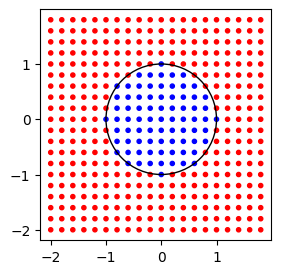

In [2]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    # grab a 2D view of the data and get limits
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step


    # make a grid of points and predict at them
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    # warning:  non-cv fit
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)

    # plot the predictions at the grid points
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)#-grid_step)
    ax.set_ylim(min_x2, max_x2)#-grid_step)
def get_model_name(model):
    ' return name of model (class) as a string '
    return str(model.__class__).split('.')[-1][:-2]
xs, ys = np.mgrid[-2:2:.2, -2:2:.2]
tgt = (xs**2 + ys**2 > 1).flatten()
data = np.c_[xs.flat, ys.flat]
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(xs, ys, c=np.where(tgt, 'r', 'b'), marker='.')
ax.set_aspect('equal');
circ = plt.Circle((0,0), 1, color='k', fill=False)
ax.add_patch(circ)

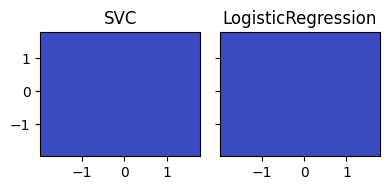

In [6]:
shootout_linear = [svm.SVC(kernel='linear'), linear_model.LogisticRegression()]
fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
for mod, ax in zip(shootout_linear, axes):
    plot_boundary(ax, data, tgt, mod, [0,1])
    ax.set_title(get_model_name(mod))
plt.tight_layout()
plt.show()

In [8]:
X = data
y = np.asarray(tgt)
for model in shootout_linear:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    pipe.fit(X, y)
    y_hat = pipe.predict(X)
    f1_macro = f1_score(y, y_hat, average='macro')
    print(f"{model.__class__.__name__}: F1 (macro) = {f1_macro:.4f}")

SVC: F1 (macro) = 0.4467
LogisticRegression: F1 (macro) = 0.4467


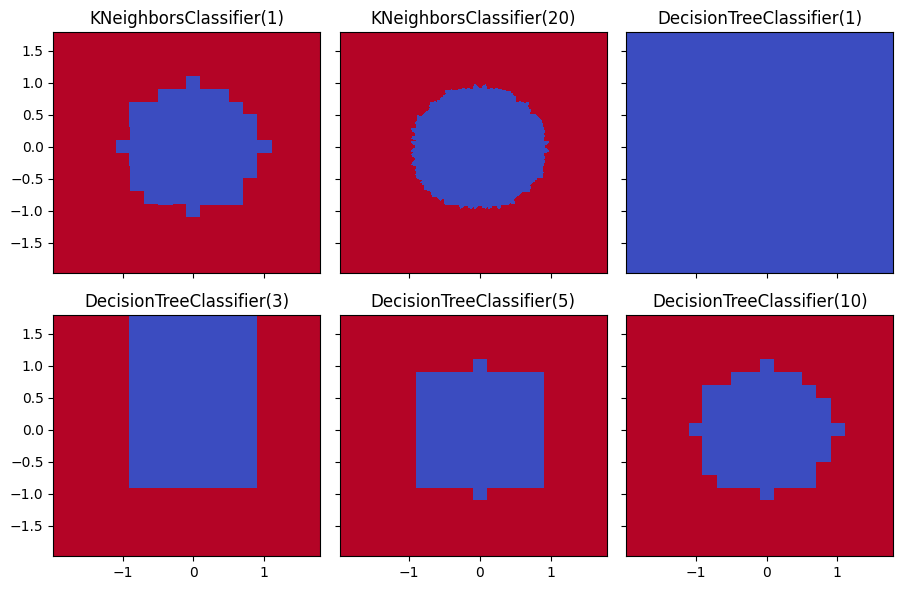

In [12]:
knc_p, dtc_p = [1, 20], [1, 3, 5, 10]
shootout_nonlinear = (
        [(KNeighborsClassifier(n_neighbors=p), p) for p in knc_p] +
        [(DecisionTreeClassifier(max_depth=p), p) for p in dtc_p]
)

fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for (mod, param), ax in zip(shootout_nonlinear, axes.flat):
    plot_boundary(ax, data, tgt, mod, [0,1])
    ax.set_title(get_model_name(mod) + "({})".format(param))

plt.tight_layout()

Novi oblik podataka: (400, 4)
Prvi red: [-2. -2.  4.  4.]


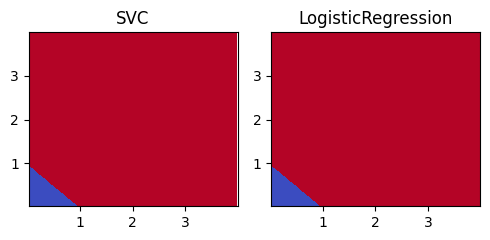

In [13]:
new_data = np.concatenate([data, data**2], axis=1)
print("Novi oblik podataka:", new_data.shape)
print("Prvi red:", new_data[0])


fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
for mod, ax in zip(shootout_linear, axes):
    plot_boundary(ax, new_data, tgt, mod, [2, 3])
    ax.set_title(get_model_name(mod))
plt.tight_layout()